In this notebook, we compare multiple loss functions to find train good models for the jaguar reidentification. We use DINOv3 as backbone. After embedding we use a newly trained models using ArcFaceLoss. We compare the identity-based mAP for the validation set, the number of parameters and the training time. The notebooks compares the following loss functions:
1. ArcFace
2. CosFace
3. SphereFace
4. Cross-Entropy
5. Focal Loss

## 1. Setup and Configuration

In [23]:
EXPERIMENT_NAME = "loss"
RANDOM_SEED = 51

import os

os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

from pathlib import Path
import sys

PROJECT_PATH = Path.cwd().parent
sys.path.insert(0, str(PROJECT_PATH))

from dotenv import load_dotenv
import math

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
from PIL import Image
from tabulate import tabulate
import wandb
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import timm
from timm.data import resolve_data_config
from timm.data.transforms_factory import create_transform
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from src.utils import (
    get_device,
    set_seeds,
    create_deterministic_training_dataloader,
)
from src.visualization import visualize_embeddings_mds

set_seeds(RANDOM_SEED)

print(f"PyTorch version: {torch.__version__}")

All random seeds set to 51 for reproducibility
PyTorch version: 2.9.1+cu128


In [2]:
# Define paths
DATA_PATH = PROJECT_PATH / "data"
OUTPUT_PATH = PROJECT_PATH / "output" / EXPERIMENT_NAME
OUTPUT_PATH_SHARED = PROJECT_PATH / "output" / "shared"
CHECKPOINT_PATH = PROJECT_PATH / "checkpoints" / EXPERIMENT_NAME
EMBEDDINGS_PATH = CHECKPOINT_PATH / "embeddings"

DATA_PATH.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH_SHARED.mkdir(parents=True, exist_ok=True)
CHECKPOINT_PATH.mkdir(parents=True, exist_ok=True)
EMBEDDINGS_PATH.mkdir(parents=True, exist_ok=True)

# Load environment variables from .env file
load_dotenv(dotenv_path=PROJECT_PATH / ".env")

True

In [3]:
# Configuration
config = {       
    # Dinov3 Model
    "dinov3_model": "hf-hub:timm/vit_base_patch16_dinov3.lvd1689m",
    "dinov3_input_size": 224,

    # Model
    "embedding_dim": 256,
    "hidden_dim": 512,
    "dropout": 0.3,
    
    # ArcFace
    "arcface_margin": 0.5,
    "arcface_scale": 64.0,
    
    # CosFace
    "cosface_margin": 0.35,
    "cosface_scale": 30.0,
    
    # SphereFace
    "sphereface_margin": 4,
    "sphereface_scale": 64.0,
    
    # ProxyAnchor
    "proxyanchor_margin": 0.1,
    "proxyanchor_alpha": 32.0,
    
    # SubCenterArcFace
    "subcenter_arcface_margin": 0.5,
    "subcenter_arcface_scale": 64.0,
    "subcenter_arcface_num_subcenters": 3,
    
    # BatchHardTriplet
    "batch_hard_triplet_margin": 0.3,
    
    # Training
    "batch_size": 32,
    "learning_rate": 1e-4,
    "weight_decay": 1e-4,
    "num_epochs": 200,
    "patience": 10,
    "val_split": 0.2,
    
    # Reproducibility
    "seed": RANDOM_SEED,
}

print("Configuration:")
for key, value in config.items():
    print(f"  {key}: {value}")

Configuration:
  dinov3_model: hf-hub:timm/vit_base_patch16_dinov3.lvd1689m
  dinov3_input_size: 224
  embedding_dim: 256
  hidden_dim: 512
  dropout: 0.3
  arcface_margin: 0.5
  arcface_scale: 64.0
  cosface_margin: 0.35
  cosface_scale: 30.0
  sphereface_margin: 4
  sphereface_scale: 64.0
  proxyanchor_margin: 0.1
  proxyanchor_alpha: 32.0
  subcenter_arcface_margin: 0.5
  subcenter_arcface_scale: 64.0
  subcenter_arcface_num_subcenters: 3
  batch_hard_triplet_margin: 0.3
  batch_size: 32
  learning_rate: 0.0001
  weight_decay: 0.0001
  num_epochs: 200
  patience: 10
  val_split: 0.2
  seed: 51


In [4]:
# Initialize Weights and Biases for experiment tracking
# Key hyperparameters are tracked explicitly for easy filtering in W&B dashboard
if not os.getenv("WANDB_API_KEY"):
    print("Warning: WANDB_API_KEY not found in environment variables. W&B logging will be disabled.")
else:
    wandb.login()

    wandb.init(
        project="jaguar-reidentification",
        config=config,
        name=EXPERIMENT_NAME,
    )

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: karl-schuetz (karl-schuetz-hasso-plattner-institut) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## Data Loading

In [5]:
# Load training data
train_df = pd.read_csv(DATA_PATH / "train.csv").set_index("filename")

print(f"Training dataset:")
print(f"  Total images: {len(train_df)}")
print(f"  Unique identities: {train_df['ground_truth'].nunique()}")
print(f"\nSample rows:")
print(train_df.head())

Training dataset:
  Total images: 1895
  Unique identities: 31

Sample rows:
               ground_truth
filename                   
train_0001.png        Abril
train_0002.png        Abril
train_0003.png        Abril
train_0004.png       Akaloi
train_0005.png       Akaloi


Dataset split:
  Training:   1516 images (80%)
  Validation: 379 images (20%)

Identity coverage:
  Identities in training:   31
  Identities in validation: 31
  Overlap: 31
  All identities present in both sets


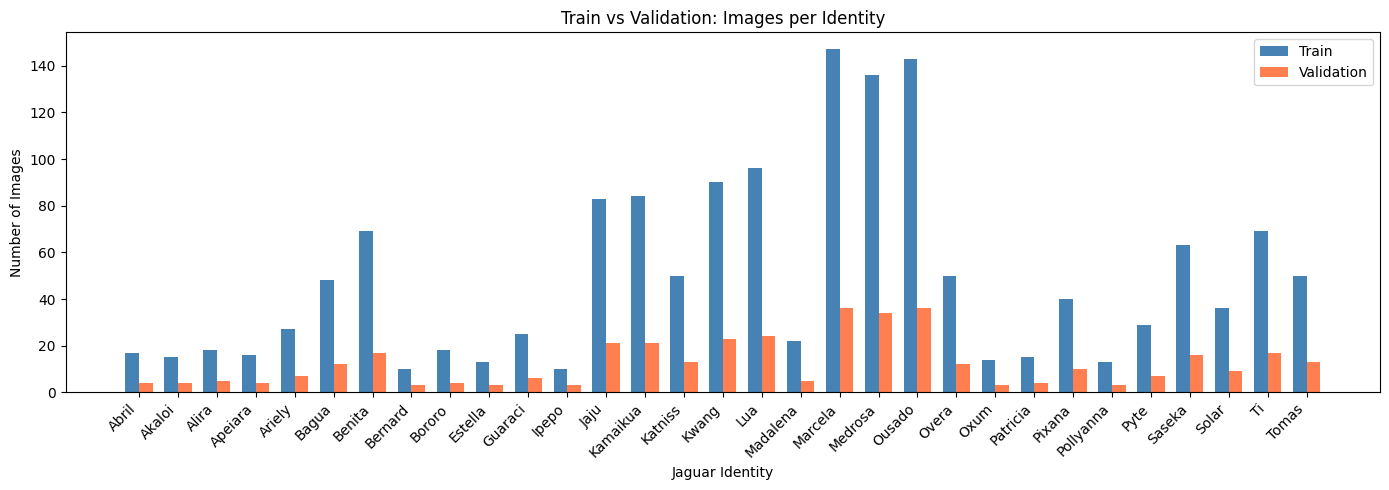


Logged identity distributions to W&B
  Train samples per identity: 10 - 147 (mean: 48.9)
  Val samples per identity: 3 - 36 (mean: 12.2)


In [6]:
# Create stratified train/validation split
# This ensures all identities appear in both sets

# Encode labels to integers
label_encoder = LabelEncoder()
train_df['label_encoded'] = label_encoder.fit_transform(train_df['ground_truth'])
num_classes = len(label_encoder.classes_)

# Stratified split: each identity's images are split proportionally
train_data, val_data = train_test_split(
    train_df,
    test_size=config["val_split"],
    random_state=config["seed"],
    stratify=train_df['ground_truth']  # Ensures proportional representation
)

print(f"Dataset split:")
print(f"  Training:   {len(train_data)} images ({100*(1-config['val_split']):.0f}%)")
print(f"  Validation: {len(val_data)} images ({100*config['val_split']:.0f}%)")

# Verify all identities are in both sets
train_identities = set(train_data['ground_truth'].unique())
val_identities = set(val_data['ground_truth'].unique())

print(f"\nIdentity coverage:")
print(f"  Identities in training:   {len(train_identities)}")
print(f"  Identities in validation: {len(val_identities)}")
print(f"  Overlap: {len(train_identities & val_identities)}")

if train_identities == val_identities:
    print("  All identities present in both sets")

# Log identity distributions to W&B
train_counts = train_data['ground_truth'].value_counts().sort_index()
val_counts = val_data['ground_truth'].value_counts().sort_index()

# Create a comparison table for W&B
distribution_df = pd.DataFrame({
    'identity': train_counts.index,
    'train_count': train_counts.values,
    'val_count': val_counts.values,
    'total_count': train_counts.values + val_counts.values,
    'train_ratio': train_counts.values / (train_counts.values + val_counts.values)
})

# Log table and summary stats to W&B
wandb.log({
    "identity_distribution_table": wandb.Table(dataframe=distribution_df),
    "num_identities": num_classes,
    "train_samples": len(train_data),
    "val_samples": len(val_data),
    "train_samples_per_identity": wandb.Histogram(train_counts.values),
    "val_samples_per_identity": wandb.Histogram(val_counts.values),
})

# Visualize train vs val distribution
fig, ax = plt.subplots(figsize=(14, 5))
width = 0.35
x = np.arange(len(train_counts))
ax.bar(x - width/2, train_counts.values, width, label='Train', color='steelblue')
ax.bar(x + width/2, val_counts.values, width, label='Validation', color='coral')
ax.set_xlabel('Jaguar Identity')
ax.set_ylabel('Number of Images')
ax.set_title('Train vs Validation: Images per Identity')
ax.set_xticks(x)
ax.set_xticklabels(train_counts.index, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
wandb.log({"train_val_distribution": wandb.Image(fig)})
plt.show()

print(f"\nLogged identity distributions to W&B")
print(f"  Train samples per identity: {train_counts.min()} - {train_counts.max()} (mean: {train_counts.mean():.1f})")
print(f"  Val samples per identity: {val_counts.min()} - {val_counts.max()} (mean: {val_counts.mean():.1f})")

## Training Utils

In [7]:
device = get_device()
print(f"Using device: {device}")

Using CUDA GPU
Using device: cuda


In [8]:
num_workers = min(8, os.cpu_count())
print(f"Using num_workers={num_workers} for DataLoader")

Using num_workers=8 for DataLoader


In [9]:
filenames = train_df.index.astype(str)
train_mask = filenames.isin(train_data.index.astype(str))

filenames = filenames.to_numpy()
labels = train_df["label_encoded"].to_numpy()
image_paths = [DATA_PATH / "train" / fn for fn in filenames]

In [10]:
@torch.no_grad()
def extract_embeddings(model, data_loader, desc="Extracting embeddings"):
    """Extract embeddings for a batch of images."""
    model.eval()
    embeddings = []

    for batch in tqdm(data_loader, desc=desc):
        batch = batch.to(device)
        with torch.no_grad():
            emb = model(batch)
        embeddings.append(emb.cpu().numpy())

    return np.concatenate(embeddings, axis=0)

print("Embedding extraction function defined")

Embedding extraction function defined


In [11]:
# Extract baseline embeddings for training data

def _load_cached_embeddings(cache_path, expected_filenames):
    z = np.load(cache_path, allow_pickle=True)
    cached_embeddings = z["embeddings"]
    cached_filenames = z["filenames"].tolist() if isinstance(z["filenames"], np.ndarray) else list(z["filenames"])

    if len(cached_filenames) != len(expected_filenames):
        return None

    if set(cached_filenames) != set(expected_filenames):
        return None

    idx = {fn: i for i, fn in enumerate(cached_filenames)}
    return np.stack([cached_embeddings[idx[fn]] for fn in expected_filenames], axis=0)

def get_embeddings(model, cache_path, data_loader):
    embeddings = None
    if cache_path.exists():
        embeddings = _load_cached_embeddings(cache_path, filenames)
        if embeddings is not None:
            print(f"Loaded cached embeddings from {cache_path}")
            print(f"Embeddings shape: {embeddings.shape}")
            
    if embeddings is None:
        print(f"Extracting embeddings for {len(data_loader)} images...")
        embeddings = extract_embeddings(
            model,
            data_loader
        )
        np.savez_compressed(
            cache_path,
            embeddings=embeddings,
            filenames=np.array(filenames, dtype=object),
        )
        print(f"Saved embeddings cache to {cache_path}")
        print(f"Embeddings shape: {embeddings.shape}")
        
    return embeddings


In [12]:
train_labels = train_data.loc[filenames[train_mask], "label_encoded"].values
val_labels = val_data.loc[filenames[~train_mask], "label_encoded"].values

In [13]:
class EmbeddingProjection(nn.Module):
    """
    Projects embeddings to a lower-dimensional space.
    Architecture: input_dim -> hidden_dim -> output_dim
    """
    
    def __init__(self, input_dim=1536, hidden_dim=512, output_dim=256, dropout=0.3):
        super().__init__()
        
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            
            nn.Linear(hidden_dim, output_dim),
            nn.BatchNorm1d(output_dim),
        )
        
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
                
    def reset(self):
        self._init_weights()
    
    def forward(self, x):
        return self.network(x)

print("EmbeddingProjection defined")

EmbeddingProjection defined


In [14]:
class ImageDataset(Dataset):
    """PyTorch Dataset for images."""
    
    def __init__(self, filepaths, preprocess):
        self.filepaths = filepaths
        self.preprocess = preprocess
        
    def blur_background(self, img):
        img = np.array(img.convert("RGBA"))

        if img.shape[2] != 4:
            raise ValueError("Input image must have 4 channels (RGBA)")

        rgb = img[:, :, :3]
        alpha = img[:, :, 3]

        blurred = cv2.GaussianBlur(rgb, (0, 0), sigmaX=10, sigmaY=10)

        mask = alpha == 0
        rgb = rgb.copy()
        rgb[mask] = blurred[mask]

        return Image.fromarray(rgb)

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        image = Image.open(self.filepaths[idx]).convert("RGBA")
        image = self.blur_background(image)
        return self.preprocess(image)

In [15]:
class EmbeddingDataset(Dataset):
    """PyTorch Dataset for pre-computed embeddings."""
    
    def __init__(self, embeddings, labels):
        self.embeddings = torch.FloatTensor(embeddings)
        self.labels = torch.LongTensor(labels)
        
        assert len(self.embeddings) == len(self.labels), "Embeddings and labels must have the same length"
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.embeddings[idx], self.labels[idx]

In [16]:
def compute_validation_map(model, val_loader):
    """
    Compute identity-balanced mean Average Precision on validation set.
    
    This simulates the competition metric:
    1. For each query, rank all other images by cosine similarity
    2. Compute Average Precision based on where true matches appear
    3. Average APs within each identity, then average across identities
    """
    model.eval()
    
    val_embeddings = []
    val_labels = []
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            embeddings = model(images)
            embeddings = F.normalize(embeddings, p=2, dim=1)
            val_embeddings.append(embeddings.cpu().numpy())
            val_labels.append(labels.cpu().numpy())

    val_embeddings = np.concatenate(val_embeddings)
    val_labels = np.concatenate(val_labels)

    # Compute cosine similarity matrix
    sim_matrix = cosine_similarity(val_embeddings)
    np.fill_diagonal(sim_matrix, -1)  # Exclude self-similarity

    # Compute AP for each query
    query_aps = {}
    
    for query_idx in range(len(val_labels)):
        query_label = val_labels[query_idx]
        
        # Get similarities to all gallery images (excluding self)
        similarities = sim_matrix[query_idx]
        
        # True labels for gallery
        gallery_labels = val_labels.copy()
        is_match = (gallery_labels == query_label).astype(int)
        is_match[query_idx] = 0  # Exclude self
        
        # Sort by similarity descending
        sorted_indices = np.argsort(-similarities)
        sorted_matches = is_match[sorted_indices]
        
        # Compute Average Precision
        n_positives = sorted_matches.sum()
        if n_positives == 0:
            continue
        
        cumsum = np.cumsum(sorted_matches)
        precision_at_k = cumsum / np.arange(1, len(sorted_matches) + 1)
        ap = np.sum(precision_at_k * sorted_matches) / n_positives
        
        query_aps[query_idx] = (query_label, ap)
    
    # Group by identity and compute identity-balanced mAP
    identity_aps = {}
    for query_idx, (label, ap) in query_aps.items():
        if label not in identity_aps:
            identity_aps[label] = []
        identity_aps[label].append(ap)
    
    # Average within identity, then across identities
    identity_mean_aps = [np.mean(aps) for aps in identity_aps.values()]
    balanced_map = np.mean(identity_mean_aps)
    
    return balanced_map


print("Validation mAP function defined")

Validation mAP function defined


In [17]:
def train_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    total = 0
    
    pbar = tqdm(loader, desc='Training', leave=False)
    for embeddings, labels in pbar:
        embeddings, labels = embeddings.to(device), labels.to(device)
        
        # Forward pass
        finetuned_embeddings = model(embeddings)
        loss = criterion(finetuned_embeddings, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Metrics
        total_loss += loss.item()
        total += labels.size(0)
        
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_loss = total_loss / len(loader)
    return avg_loss


def validate_epoch(model, loader, criterion, device):
    """Validate for one epoch."""
    model.eval()
    total_loss = 0
    total = 0
    
    with torch.no_grad():
        pbar = tqdm(loader, desc='Validation', leave=False)
        for embeddings, labels in pbar:
            embeddings, labels = embeddings.to(device), labels.to(device)

            finetuned_embeddings = model(embeddings)
            loss = criterion(finetuned_embeddings, labels)

            total_loss += loss.item()
            total += labels.size(0)
            
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_loss = total_loss / len(loader)
    return avg_loss


print("Training and validation functions defined")

Training and validation functions defined


In [18]:
def train(model, train_loader, val_loader, criterion, optimizer, scheduler, device, name):
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [],
        'val_map': [], 'lr': []
    }

    best_val_map = 0.0
    patience_counter = 0
    best_epoch = 0

    print(f"Starting training for {config['num_epochs']} epochs...")
    print("=" * 70)

    for epoch in range(config['num_epochs']):
        print(f"\nEpoch {epoch+1}/{config['num_epochs']}")
        
        # Train
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        
        # Validate
        val_loss = validate_epoch(model, val_loader, criterion, device)
        
        # Compute validation mAP
        val_map = compute_validation_map(
            model, 
            val_loader,
        )
        
        # Update scheduler
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']
        
        # Store history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_map'].append(val_map)
        history['lr'].append(current_lr)
        
        # Log to W&B
        wandb.log({
            'model': name,
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'val_map': val_map,
            'learning_rate': current_lr,
        })
        
        # Print summary
        print(f"  Train Loss: {train_loss:.4f}")
        print(f"  Val Loss:   {val_loss:.4f}")
        print(f"  Val mAP:    {val_map:.4f} | LR: {current_lr:.2e}")
        
        # Checkpoint best model
        if val_map > best_val_map:
            best_val_map = val_map
            best_epoch = epoch + 1
            patience_counter = 0

            checkpoint_path = CHECKPOINT_PATH / f"model_best_{name}.pth"
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': val_loss,
                'val_map': val_map,
                'config': config,
                'label_encoder_classes': label_encoder.classes_.tolist(),
                'num_classes': num_classes,
                'name': name
            }, checkpoint_path)
            
            print(f"  [New best model saved]")
        else:
            patience_counter += 1
            print(f"  No improvement. Patience: {patience_counter}/{config['patience']}")
        
        # Early stopping
        if patience_counter >= config['patience']:
            print(f"\nEarly stopping triggered after {epoch+1} epochs")
            break

    print("\n" + "=" * 70)
    print(f"Training complete!")
    print(f"Best epoch: {best_epoch}, Val mAP: {best_val_map:.4f}")

    return history, best_val_map, best_epoch

print("Train function defined")

Train function defined


In [19]:
def plot_history(history, best_epoch):
    # Plot training curves
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))

    epochs_range = range(1, len(history['train_loss']) + 1)

    # Loss
    axes[0].plot(epochs_range, history['train_loss'], 'b-', label='Train')
    axes[0].plot(epochs_range, history['val_loss'], 'r-', label='Validation')
    axes[0].axvline(x=best_epoch, color='g', linestyle='--', alpha=0.7, label=f'Best ({best_epoch})')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # mAP
    axes[1].plot(epochs_range, history['val_map'], 'purple', linewidth=2)
    axes[1].axvline(x=best_epoch, color='g', linestyle='--', alpha=0.7)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('mAP')
    axes[1].set_title('Validation mAP (Identity-Balanced)')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    
    return fig


In [20]:
# Load Dino model
print("Loading Dino model...")
dino = timm.create_model(
    config["dinov3_model"],
    pretrained=True
)
dino.eval()
dino.to(device)
dino.compile()

dino_config = resolve_data_config({}, model=dino)
dino_preprocess = create_transform(**dino_config, is_training=False)

dino_num_params = sum(p.numel() for p in dino.parameters())

print(f"Model loaded successfully")
print(f"  Parameters: {dino_num_params:,}")
print(f"  Preprocessing: {dino_config}")

# Get the embedding dimension from the model
with torch.no_grad():
    input_size = dino_config["input_size"]
    dummy_input = torch.randn(1, input_size[0], input_size[1], input_size[2]).to(device)
    dummy_output = dino(dummy_input)
    dino_dim = dummy_output.shape[1]
    print(f"  Embedding dimension: {dino_dim}")

Loading Dino model...
Model loaded successfully
  Parameters: 85,641,216
  Preprocessing: {'input_size': [3, 256, 256], 'interpolation': 'bicubic', 'mean': [0.485, 0.456, 0.406], 'std': [0.229, 0.224, 0.225], 'crop_pct': 1.0, 'crop_mode': 'center'}
  Embedding dimension: 768


In [21]:
image_dataset = ImageDataset(image_paths, dino_preprocess)
image_loader = DataLoader(
    image_dataset,
    batch_size=config["batch_size"],
    num_workers=num_workers,
    shuffle=False
)

print(f"Image DataLoader created with {len(image_loader)} batches")

Image DataLoader created with 60 batches


In [24]:
baseline_cache_path = EMBEDDINGS_PATH / "dino_baseline_embeddings.npz"

baseline_embeddings = get_embeddings(
    dino,
    baseline_cache_path,
    image_loader
)

Extracting embeddings for 60 images...


Extracting embeddings: 100%|██████████| 60/60 [05:59<00:00,  5.99s/it]


Saved embeddings cache to /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/loss/embeddings/dino_baseline_embeddings.npz
Embeddings shape: (1895, 768)


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


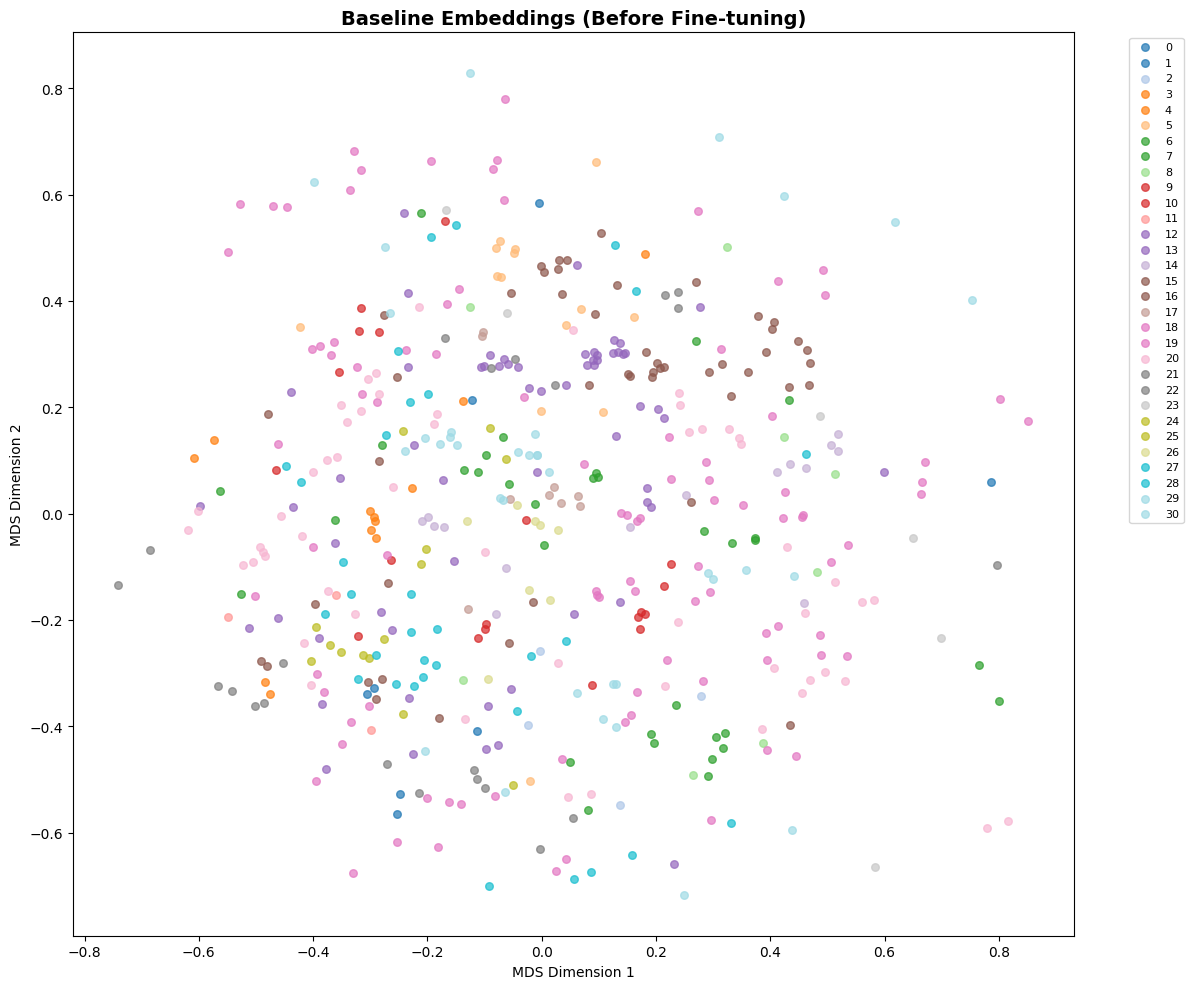

In [25]:
# Visualize DINO embeddings
fig = visualize_embeddings_mds(
    baseline_embeddings,
    labels,
    "Baseline Embeddings (Before Fine-tuning)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "baseline_embeddings_mds.png")
plt.show()

# Log to W&B
wandb.log({"baseline_embeddings_mds": wandb.Image(fig)})

In [26]:
baseline_emb_train_dataset = EmbeddingDataset(
    baseline_embeddings[train_mask],
    train_labels
)

baseline_emb_val_dataset = EmbeddingDataset(
    baseline_embeddings[~train_mask],
    val_labels
)

baseline_emb_train_loader = create_deterministic_training_dataloader(
    baseline_emb_train_dataset,
    batch_size=config["batch_size"],
)
baseline_emb_val_loader = DataLoader(
    baseline_emb_val_dataset,
    batch_size=config["batch_size"],
    num_workers=num_workers,
    shuffle=False
)

In [27]:
# Create model
model = EmbeddingProjection(
    input_dim=dino_dim,
    hidden_dim=config["hidden_dim"],
    output_dim=config["embedding_dim"],
    dropout=config["dropout"],
).to(device)

model_num_params = sum(p.numel() for p in model.parameters())

print(f"Embedding Projection Model defined:")
print(f"  Total parameters: {model_num_params:,}")

Embedding Projection Model defined:
  Total parameters: 526,592


In [28]:
# Export initial model weights for reinitialization
initial_weights_path = CHECKPOINT_PATH / "model_initial_weights.pth"
torch.save(model.state_dict(), initial_weights_path)
print(f"Initial model weights saved to {initial_weights_path}")

Initial model weights saved to /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/loss/model_initial_weights.pth


In [29]:
table = [
    ["Loss Function", "Best val_mAP", "Best epoch"]
]

## ArcFace

In [30]:

class ArcFaceLoss(nn.Module):
    """
    ArcFace (Additive Angular Margin Loss) layer.
    
    The loss is computed as:
        L = -log(exp(s * cos(theta_y + m)) / (exp(s * cos(theta_y + m)) + sum(exp(s * cos(theta_j)))))
    
    where:
        - theta_y is the angle between embedding and ground truth class center
        - m is the angular margin (default 0.5 radians, about 28.6 degrees)
        - s is the feature scale (default 64)
    """
    
    def __init__(self, embedding_dim, num_classes, margin=0.5, scale=64.0):
        super().__init__()
        self.embedding_dim = embedding_dim
        self.num_classes = num_classes
        self.margin = margin
        self.scale = scale
        
        # Learnable weight matrix (class prototypes on the hypersphere)
        self.weight = nn.Parameter(torch.FloatTensor(num_classes, embedding_dim))
        nn.init.xavier_uniform_(self.weight)
        
        # Pre-compute trigonometric values for efficiency
        self.cos_m = math.cos(margin)
        self.sin_m = math.sin(margin)
        self.th = math.cos(math.pi - margin)  # Threshold for numerical stability
        self.mm = math.sin(math.pi - margin) * margin
    
    def forward(self, embeddings, labels):
        """
        Args:
            embeddings: (batch_size, embedding_dim) - will be normalized
            labels: (batch_size,) - ground truth class indices
        
        Returns:
            logits: (batch_size, num_classes) - ArcFace logits for cross-entropy loss
        """
        # Normalize embeddings and weights to unit length
        embeddings = F.normalize(embeddings, p=2, dim=1)
        weight_norm = F.normalize(self.weight, p=2, dim=1)
        
        # Compute cosine similarity: cos(theta)
        cosine = F.linear(embeddings, weight_norm)
        cosine = cosine.clamp(-1.0, 1.0)
        
        # Compute sin(theta) from cos(theta)
        sine = torch.sqrt(1.0 - torch.pow(cosine, 2))
        
        # Compute cos(theta + m) using angle addition formula
        # cos(theta + m) = cos(theta)*cos(m) - sin(theta)*sin(m)
        phi = cosine * self.cos_m - sine * self.sin_m
        
        # Apply threshold to handle theta + m >= pi
        phi = torch.where(cosine > self.th, phi, cosine - self.mm)
        
        # One-hot encode labels
        one_hot = torch.zeros(cosine.size(), device=embeddings.device)
        one_hot.scatter_(1, labels.view(-1, 1).long(), 1)
        
        # Apply margin only to ground truth class
        output = (one_hot * phi) + ((1.0 - one_hot) * cosine)
        
        # Scale logits
        logits = output * self.scale
        loss = F.cross_entropy(logits, labels)

        return loss

print(f"ArcFace Loss:")
print(f"  Embedding dim: {config['embedding_dim']}")
print(f"  Num classes: {num_classes}")
print(f"  ArcFace margin: {config['arcface_margin']}")
print(f"  ArcFace scale: {config['arcface_scale']}")

ArcFace Loss:
  Embedding dim: 256
  Num classes: 31
  ArcFace margin: 0.5
  ArcFace scale: 64.0


In [31]:
# Setup training components
model.load_state_dict(torch.load(initial_weights_path))

criterion = ArcFaceLoss(
    embedding_dim=config["embedding_dim"],
    num_classes=num_classes,
    margin=config["arcface_margin"],
    scale=config["arcface_scale"]
).to(device)

optimizer = torch.optim.AdamW(
    list(model.parameters()) + list(criterion.parameters()),
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=5,
)

print("Training components initialized:")
print(f"  Loss: ArcFaceLoss")
print(f"  Optimizer: AdamW (lr={config['learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)")

Training components initialized:
  Loss: ArcFaceLoss
  Optimizer: AdamW (lr=0.0001, weight_decay=0.0001)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)


In [32]:
# Training loop
set_seeds(config['seed'])
history, best_map, best_epoch = train(
    model, 
    baseline_emb_train_loader, 
    baseline_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="arcface"
)

wandb.log({
    "final_val_mAP_arcface": best_map,
    "best_epoch_arcface": best_epoch,
    "total_epochs_arcface": len(history['train_loss']),
})

table.append([
    "ArcFace",
    best_map,
    best_epoch
])

All random seeds set to 51 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


Training:   0%|          | 0/48 [00:00<?, ?it/s]

  Train Loss: 36.5240
  Val Loss:   32.0714
  Val mAP:    0.3486 | LR: 1.00e-04
  [New best model saved]

Epoch 2/200


  Train Loss: 31.8902
  Val Loss:   27.5759
  Val mAP:    0.3648 | LR: 1.00e-04
  [New best model saved]

Epoch 3/200


  Train Loss: 28.6609
  Val Loss:   24.2402
  Val mAP:    0.3829 | LR: 1.00e-04
  [New best model saved]

Epoch 4/200


...

  Train Loss: 0.1955
  Val Loss:   3.0498
  Val mAP:    0.8411 | LR: 5.00e-05
  No improvement. Patience: 6/10

Epoch 101/200


  Train Loss: 0.2122
  Val Loss:   3.0262
  Val mAP:    0.8383 | LR: 5.00e-05
  No improvement. Patience: 7/10

Epoch 102/200


  Train Loss: 0.1906
  Val Loss:   3.0118
  Val mAP:    0.8378 | LR: 5.00e-05
  No improvement. Patience: 8/10

Epoch 103/200


  Train Loss: 0.1521
  Val Loss:   2.9991
  Val mAP:    0.8395 | LR: 5.00e-05
  No improvement. Patience: 9/10

Epoch 104/200


  Train Loss: 0.1945
  Val Loss:   2.9773
  Val mAP:    0.8370 | LR: 5.00e-05
  No improvement. Patience: 10/10

Early stopping triggered after 104 epochs

Training complete!
Best epoch: 94, Val mAP: 0.8423


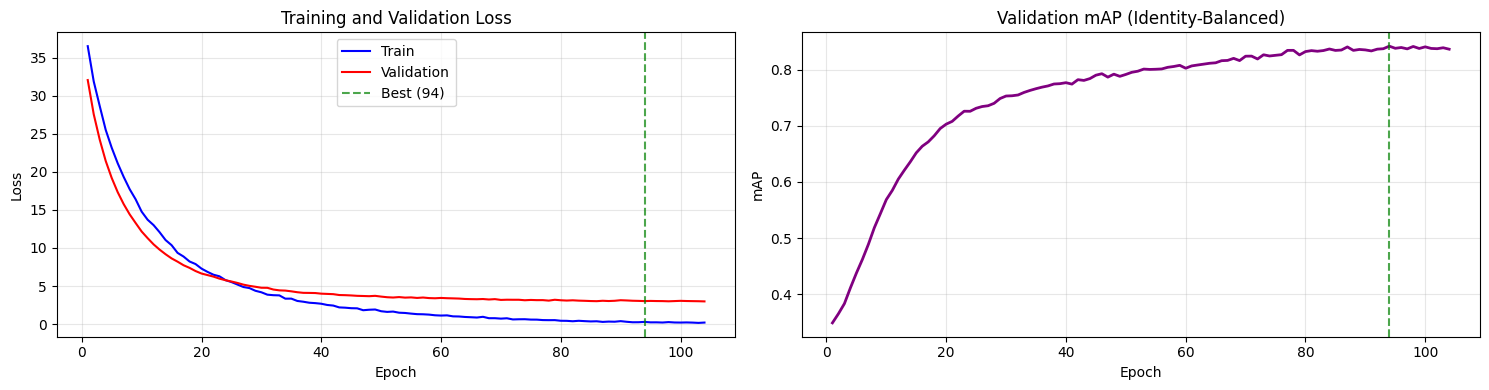

In [33]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_arcface.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_arcface": wandb.Image(fig)})

In [34]:
# Load best model
checkpoint = torch.load(CHECKPOINT_PATH / "model_best_arcface.pth", map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {CHECKPOINT_PATH}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/loss
  Val Loss: 3.0154
  Val mAP: 0.8423


In [35]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(baseline_embeddings).to(device)
    finetuned_embeddings = model(train_tensor).cpu().numpy()
    finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


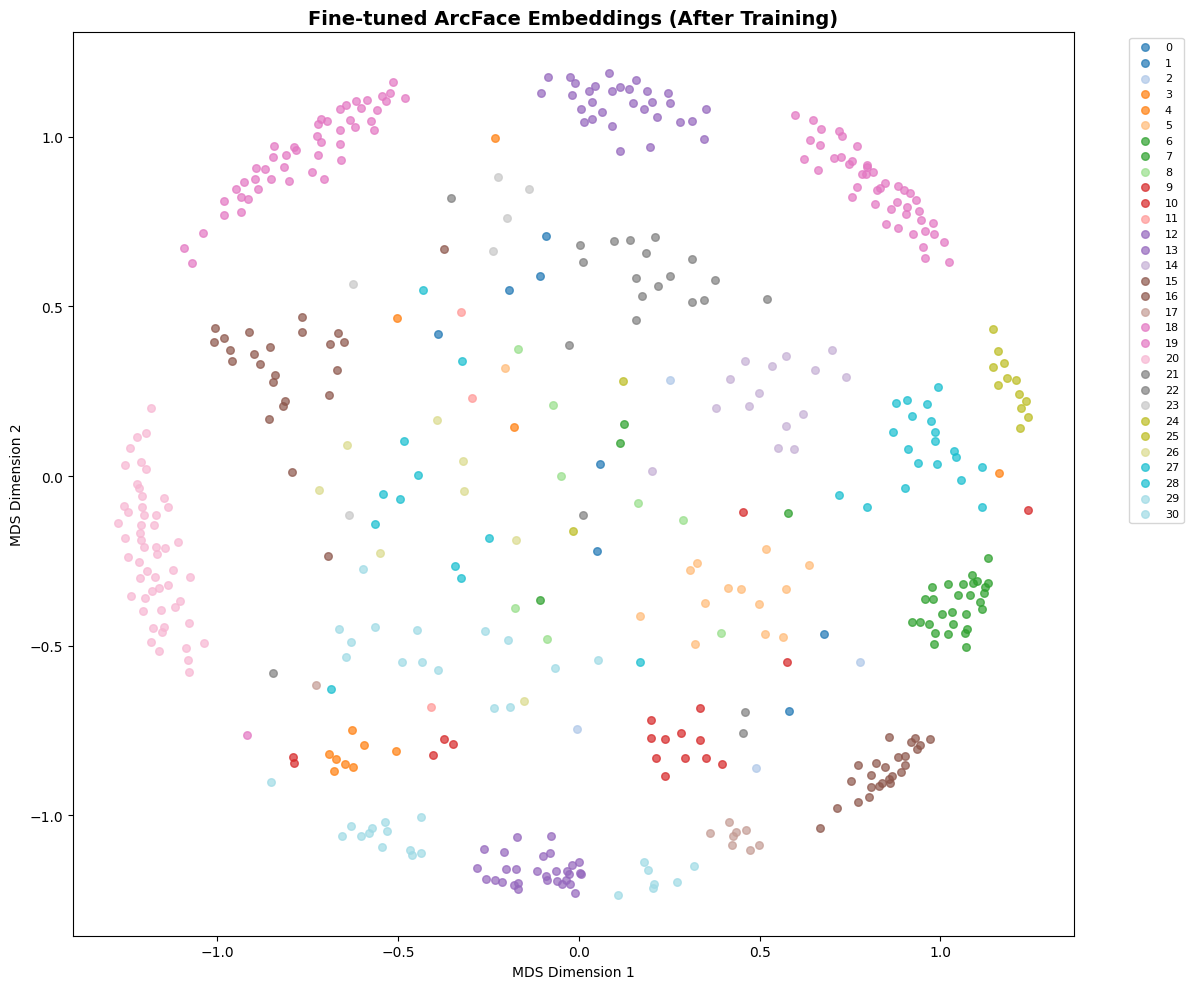

In [36]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Fine-tuned ArcFace Embeddings (After Training)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "arcface_embeddings_mds_finetuned.png")
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds_arcface": wandb.Image(fig_finetuned)})

In [37]:
del optimizer, scheduler, history
torch.cuda.empty_cache()

## CosFace

In [38]:

class CosFaceLoss(nn.Module):
    """
    TODO: Implement
    CosFace (Additive Angular Margin Loss) layer.

    The loss is computed as:
        L = -log(exp(s * cos(theta_y + m)) / (exp(s * cos(theta_y + m)) + sum(exp(s * cos(theta_j)))))
    
    where:
        - theta_y is the angle between embedding and ground truth class center
        - m is the angular margin (default 0.5 radians, about 28.6 degrees)
        - s is the feature scale (default 64)
    """
    
    def __init__(self, embedding_dim, num_classes, margin=0.5, scale=64.0):
        super().__init__()
        self.embedding_dim = embedding_dim
        self.num_classes = num_classes
        self.margin = margin
        self.scale = scale
        
        # Learnable weight matrix (class prototypes on the hypersphere)
        self.weight = nn.Parameter(torch.FloatTensor(num_classes, embedding_dim))
        nn.init.xavier_uniform_(self.weight)
        
        # Pre-compute trigonometric values for efficiency
        self.cos_m = math.cos(margin)
        self.sin_m = math.sin(margin)
        self.th = math.cos(math.pi - margin)  # Threshold for numerical stability
        self.mm = math.sin(math.pi - margin) * margin
    
    def forward(self, embeddings, labels):
        """
        Args:
            embeddings: (batch_size, embedding_dim) - will be normalized
            labels: (batch_size,) - ground truth class indices
        
        Returns:
            logits: (batch_size, num_classes) - ArcFace logits for cross-entropy loss
        """
        # Normalize embeddings and weights to unit length
        embeddings = F.normalize(embeddings, p=2, dim=1)
        weight_norm = F.normalize(self.weight, p=2, dim=1)
        
        # Compute cosine similarity: cos(theta)
        cosine = F.linear(embeddings, weight_norm)
        cosine = cosine.clamp(-1.0, 1.0)
        
        # One-hot encode labels
        one_hot = F.one_hot(labels, num_classes=cosine.size(1)).float()
        cosine_m = cosine - one_hot * self.margin
        
        # Scale logits
        logits = cosine_m * self.scale
        loss = F.cross_entropy(logits, labels)

        return loss

print(f"CosFace Loss:")
print(f"  Embedding dim: {config['embedding_dim']}")
print(f"  Num classes: {num_classes}")
print(f"  CosFace margin: {config['cosface_margin']}")
print(f"  CosFace scale: {config['cosface_scale']}")

CosFace Loss:
  Embedding dim: 256
  Num classes: 31
  CosFace margin: 0.35
  CosFace scale: 30.0


In [39]:
# Setup training components
model.load_state_dict(torch.load(initial_weights_path))

criterion = ArcFaceLoss(
    embedding_dim=config["embedding_dim"],
    num_classes=num_classes,
    margin=config["arcface_margin"],
    scale=config["arcface_scale"]
).to(device)

optimizer = torch.optim.AdamW(
    list(model.parameters()) + list(criterion.parameters()),
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=5,
)

print("Training components initialized:")
print(f"  Loss: CosFaceLoss")
print(f"  Optimizer: AdamW (lr={config['learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)")

Training components initialized:
  Loss: CosFaceLoss
  Optimizer: AdamW (lr=0.0001, weight_decay=0.0001)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)


In [40]:
# Training loop
set_seeds(config['seed'])
history, best_map, best_epoch = train(
    model, 
    baseline_emb_train_loader, 
    baseline_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="cosface"
)

wandb.log({
    "final_val_mAP_cosface": best_map,
    "best_epoch_cosface": best_epoch,
    "total_epochs_cosface": len(history['train_loss']),
})

table.append([
    "CosFace",
    best_map,
    best_epoch
])

All random seeds set to 51 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


  Train Loss: 36.4731
  Val Loss:   32.2189
  Val mAP:    0.3428 | LR: 1.00e-04
  [New best model saved]

Epoch 2/200


  Train Loss: 31.9258
  Val Loss:   27.7054
  Val mAP:    0.3614 | LR: 1.00e-04
  [New best model saved]

Epoch 3/200


  Train Loss: 28.5650
  Val Loss:   24.1547
  Val mAP:    0.3790 | LR: 1.00e-04
  [New best model saved]

Epoch 4/200


  Train Loss: 25.7334
  Val Loss:   21.3508
  Val mAP:    0.4073 | LR: 1.00e-04
  [New best model saved]

Epoch 5/200


...

  Train Loss: 0.4112
  Val Loss:   2.9959
  Val mAP:    0.8342 | LR: 5.00e-05
  No improvement. Patience: 6/10

Epoch 84/200


  Train Loss: 0.3784
  Val Loss:   2.9786
  Val mAP:    0.8343 | LR: 5.00e-05
  No improvement. Patience: 7/10

Epoch 85/200


  Train Loss: 0.3687
  Val Loss:   2.9885
  Val mAP:    0.8356 | LR: 5.00e-05
  No improvement. Patience: 8/10

Epoch 86/200


  Train Loss: 0.3818
  Val Loss:   3.0111
  Val mAP:    0.8338 | LR: 5.00e-05
  No improvement. Patience: 9/10

Epoch 87/200


  Train Loss: 0.2522
  Val Loss:   2.9639
  Val mAP:    0.8344 | LR: 5.00e-05
  No improvement. Patience: 10/10

Early stopping triggered after 87 epochs

Training complete!
Best epoch: 77, Val mAP: 0.8358


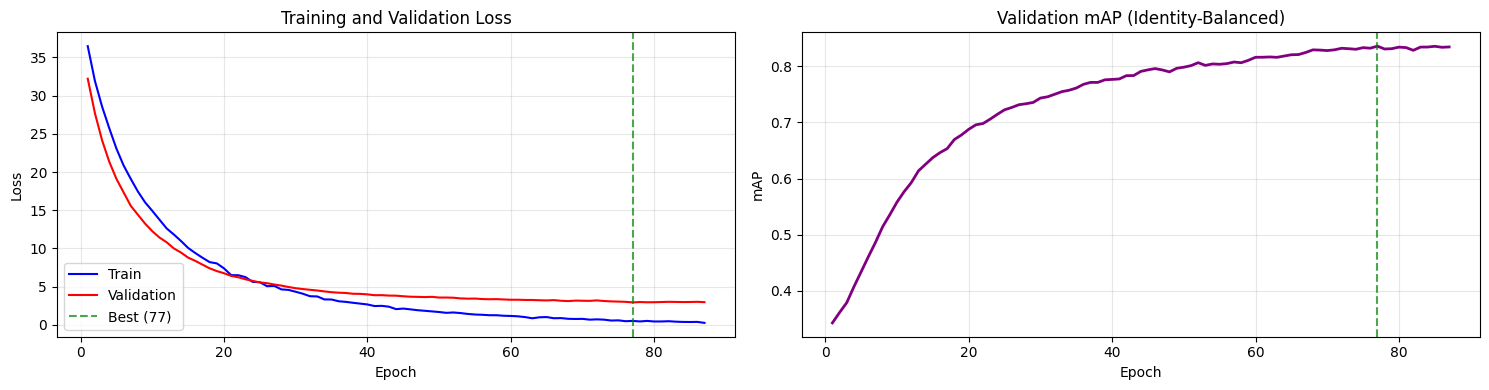

In [41]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_cosface.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_cosface": wandb.Image(fig)})

In [42]:
# Load best model
checkpoint = torch.load(CHECKPOINT_PATH / "model_best_cosface.pth", map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {CHECKPOINT_PATH}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/loss
  Val Loss: 2.9356
  Val mAP: 0.8358


In [43]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(baseline_embeddings).to(device)
    finetuned_embeddings = model(train_tensor).cpu().numpy()
    finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


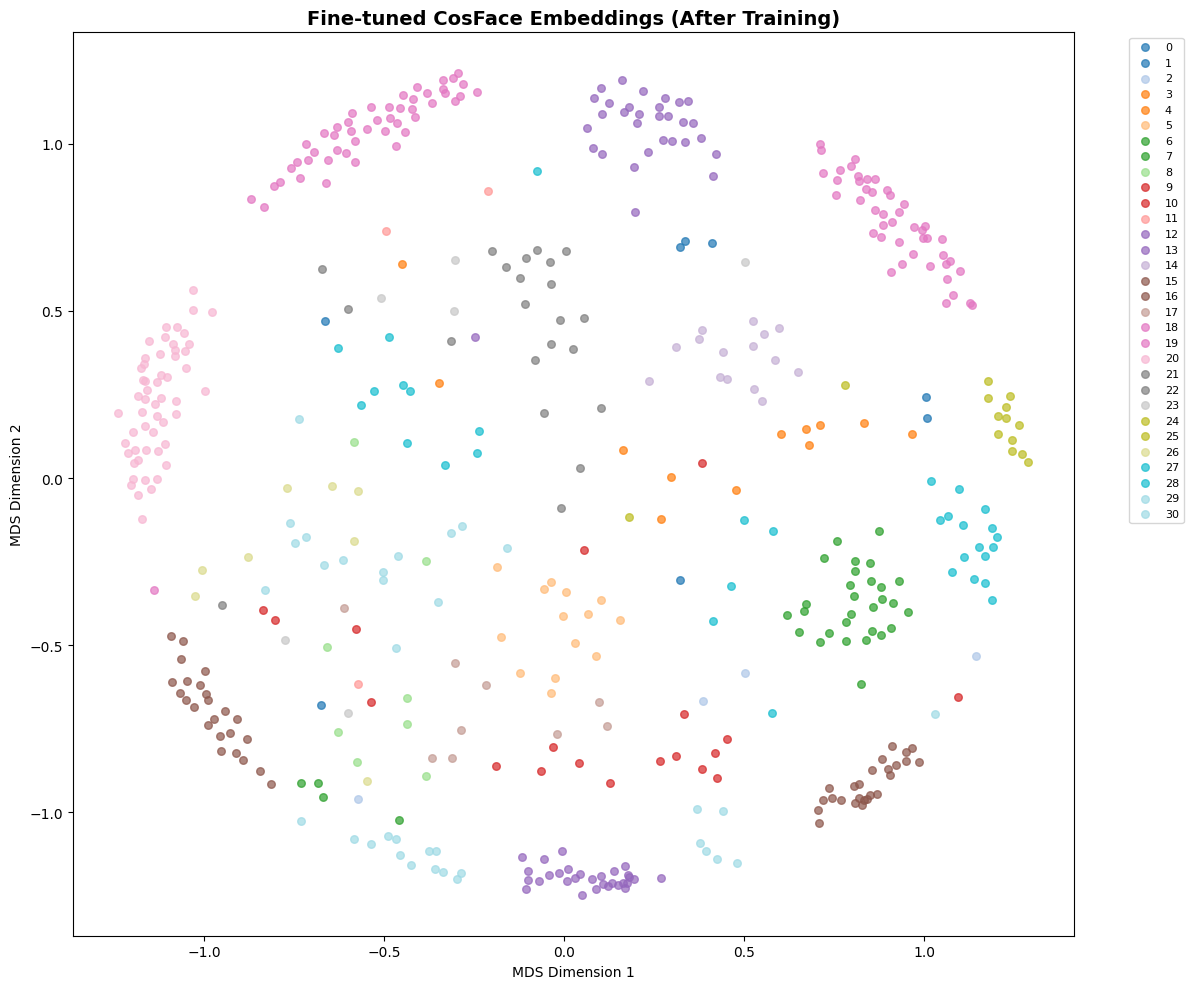

In [44]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Fine-tuned CosFace Embeddings (After Training)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "cosface_embeddings_mds_finetuned.png")
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds_cosface": wandb.Image(fig_finetuned)})

In [45]:
del optimizer, scheduler, history
torch.cuda.empty_cache()

## SphereFace

In [46]:
class SphereFaceLoss(nn.Module):
    """
    SphereFace / A-Softmax Loss

    Paper:
    SphereFace: Deep Hypersphere Embedding for Face Recognition
    https://arxiv.org/abs/1704.08063

    L = -log( exp(s * cos(m * theta_y)) /
              (exp(s * cos(m * theta_y)) + sum_j exp(s * cos(theta_j))) )
    """

    def __init__(self, embedding_dim, num_classes, margin=4, scale=64.0):
        super().__init__()

        assert isinstance(margin, int) and margin >= 1, \
            "SphereFace margin m must be an integer >= 1"

        self.embedding_dim = embedding_dim
        self.num_classes = num_classes
        self.m = margin
        self.s = scale

        self.weight = nn.Parameter(torch.empty(num_classes, embedding_dim))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, embeddings, labels):
        # Normalize features and weights
        x = F.normalize(embeddings, dim=1)
        W = F.normalize(self.weight, dim=1)

        # cos(theta)
        cosine = F.linear(x, W).clamp(-1.0, 1.0)

        # cos(m * theta) using Chebyshev polynomials
        cos_m_theta = self._cos_m_theta(cosine)

        # theta = arccos(cos(theta)) (only used to compute k, detached)
        theta = torch.acos(cosine.detach())

        # k = floor(m * theta / pi)
        k = (self.m * theta / math.pi).floor()

        # phi(theta) = (-1)^k * cos(mθ) - 2k
        phi = ((-1.0) ** k) * cos_m_theta - 2 * k

        # One-hot labels
        one_hot = F.one_hot(labels, self.num_classes).float()

        # Replace target logits
        logits = one_hot * phi + (1.0 - one_hot) * cosine
        logits *= self.s

        loss = F.cross_entropy(logits, labels)
        return loss

    def _cos_m_theta(self, cos_theta):
        """
        Compute cos(m * theta) via Chebyshev polynomials.
        """
        if self.m == 1:
            return cos_theta
        elif self.m == 2:
            return 2 * cos_theta**2 - 1
        elif self.m == 3:
            return 4 * cos_theta**3 - 3 * cos_theta
        elif self.m == 4:
            return 8 * cos_theta**4 - 8 * cos_theta**2 + 1
        elif self.m == 5:
            return 16 * cos_theta**5 - 20 * cos_theta**3 + 5 * cos_theta
        else:
            # Recursive Chebyshev (rarely used in practice)
            T0 = torch.ones_like(cos_theta)
            T1 = cos_theta
            for _ in range(2, self.m + 1):
                T2 = 2 * cos_theta * T1 - T0
                T0, T1 = T1, T2
            return T1

print(f"SphereFace Loss:")
print(f"  Embedding dim: {config['embedding_dim']}")
print(f"  Num classes: {num_classes}")
print(f"  SphereFace margin: {config['sphereface_margin']}")
print(f"  SphereFace scale: {config['sphereface_scale']}")

SphereFace Loss:
  Embedding dim: 256
  Num classes: 31
  SphereFace margin: 4
  SphereFace scale: 64.0


In [47]:
# Setup training components
model.load_state_dict(torch.load(initial_weights_path))

criterion = SphereFaceLoss(
    embedding_dim=config["embedding_dim"],
    num_classes=num_classes,
    margin=config["sphereface_margin"],
    scale=config["sphereface_scale"]
).to(device)

optimizer = torch.optim.AdamW(
    list(model.parameters()) + list(criterion.parameters()),
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=5,
)

print("Training components initialized:")
print(f"  Loss: SphereFaceLoss")
print(f"  Optimizer: AdamW (lr={config['learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)")

Training components initialized:
  Loss: SphereFaceLoss
  Optimizer: AdamW (lr=0.0001, weight_decay=0.0001)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)


In [48]:
# Training loop
set_seeds(config['seed'])
history, best_map, best_epoch = train(
    model, 
    baseline_emb_train_loader, 
    baseline_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="sphereface"
)

wandb.log({
    "final_val_mAP_sphereface": best_map,
    "best_epoch_sphereface": best_epoch,
    "total_epochs_sphereface": len(history['train_loss']),
})

table.append([
    "SphereFace",
    best_map,
    best_epoch
])

All random seeds set to 51 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


  Train Loss: 198.0143
  Val Loss:   189.8120
  Val mAP:    0.3457 | LR: 1.00e-04
  [New best model saved]

Epoch 2/200


  Train Loss: 186.4463
  Val Loss:   169.4487
  Val mAP:    0.3692 | LR: 1.00e-04
  [New best model saved]

Epoch 3/200


  Train Loss: 170.1935
  Val Loss:   153.6357
  Val mAP:    0.3987 | LR: 1.00e-04
  [New best model saved]

Epoch 4/200


  Train Loss: 158.1420
  Val Loss:   141.9325
  Val mAP:    0.4289 | LR: 1.00e-04
  [New best model saved]

Epoch 5/200


...

  Train Loss: 7.4625
  Val Loss:   17.4534
  Val mAP:    0.8571 | LR: 5.00e-05
  No improvement. Patience: 6/10

Epoch 173/200


  Train Loss: 8.2572
  Val Loss:   17.6655
  Val mAP:    0.8531 | LR: 5.00e-05
  No improvement. Patience: 7/10

Epoch 174/200


  Train Loss: 7.7435
  Val Loss:   17.4424
  Val mAP:    0.8592 | LR: 5.00e-05
  No improvement. Patience: 8/10

Epoch 175/200


  Train Loss: 7.4692
  Val Loss:   17.4107
  Val mAP:    0.8576 | LR: 5.00e-05
  No improvement. Patience: 9/10

Epoch 176/200


  Train Loss: 7.2827
  Val Loss:   17.5409
  Val mAP:    0.8520 | LR: 5.00e-05
  No improvement. Patience: 10/10

Early stopping triggered after 176 epochs

Training complete!
Best epoch: 166, Val mAP: 0.8623


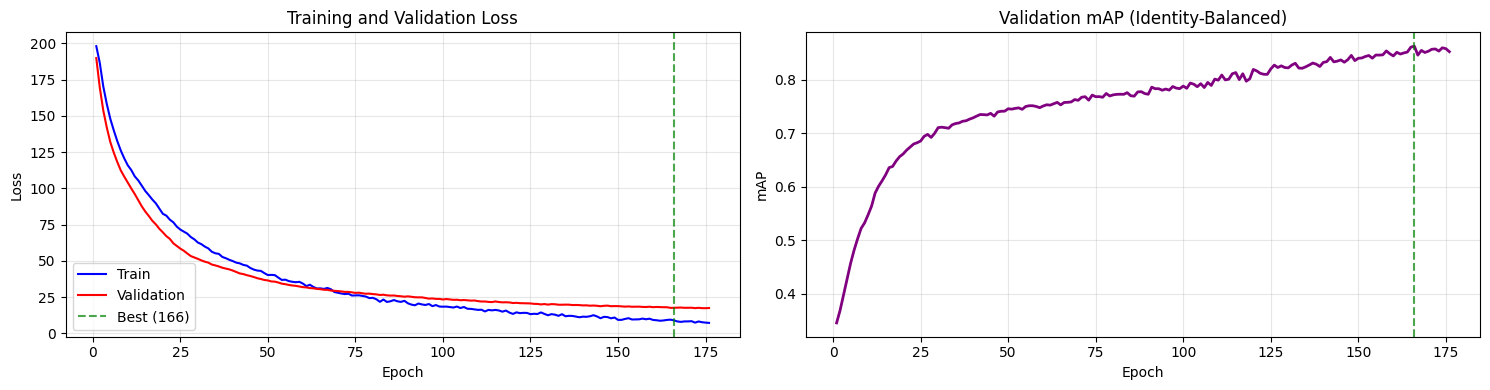

In [49]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_sphereface.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_sphereface": wandb.Image(fig)})

In [50]:
# Load best model
checkpoint = torch.load(CHECKPOINT_PATH / "model_best_sphereface.pth", map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {CHECKPOINT_PATH}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/loss
  Val Loss: 17.7013
  Val mAP: 0.8623


In [51]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(baseline_embeddings).to(device)
    finetuned_embeddings = model(train_tensor).cpu().numpy()
    finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


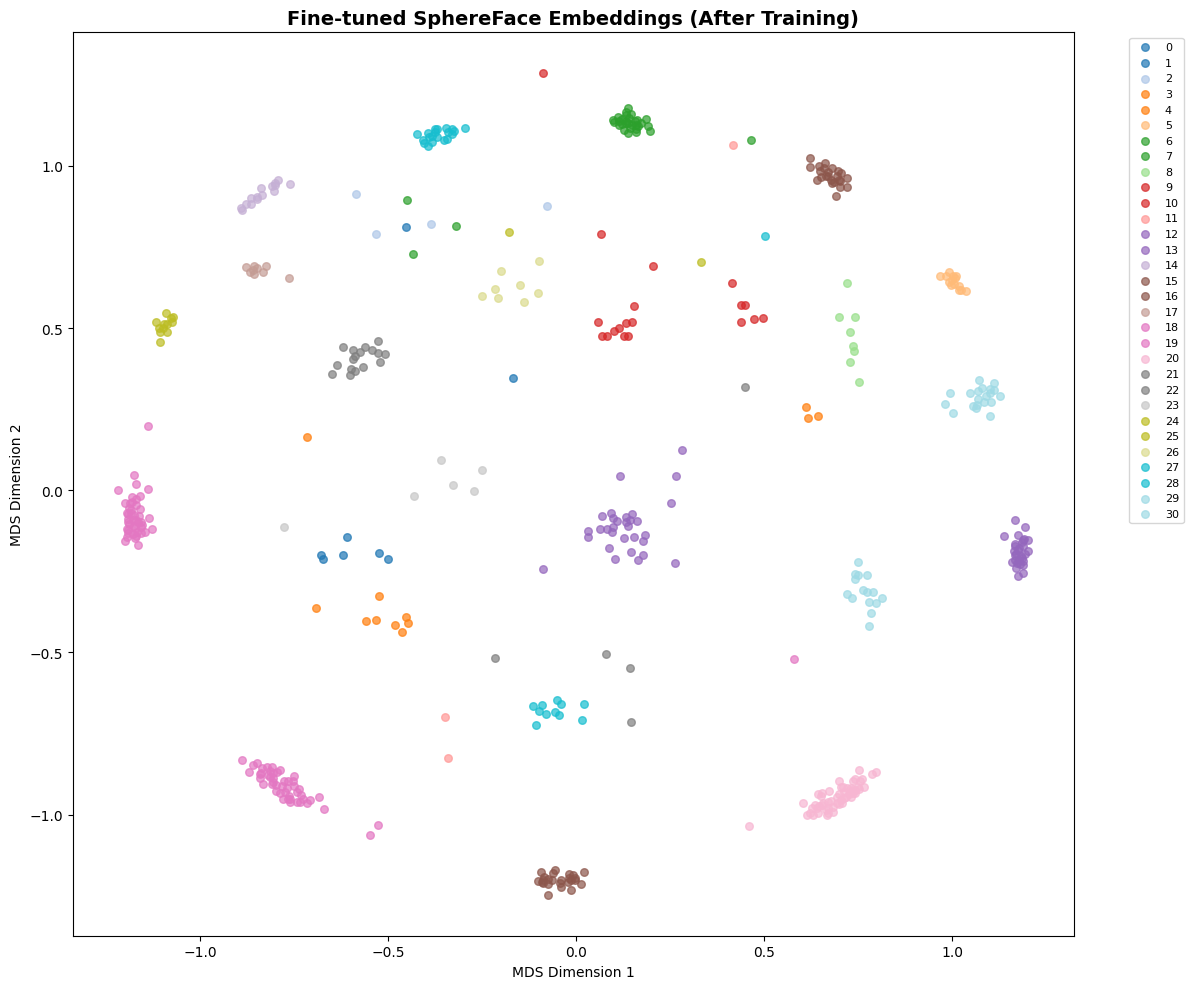

In [52]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Fine-tuned SphereFace Embeddings (After Training)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "sphereface_embeddings_mds_finetuned.png")
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds_sphereface": wandb.Image(fig_finetuned)})

In [53]:
del optimizer, scheduler, history
torch.cuda.empty_cache()

## Proxy Anchor Loss

In [54]:
class ProxyAnchorLoss(nn.Module):
    def __init__(self, num_classes, embedding_dim, margin=0.1, alpha=32):
        super().__init__()
        self.proxies = nn.Parameter(torch.randn(num_classes, embedding_dim))
        nn.init.kaiming_normal_(self.proxies, mode='fan_out')
        self.margin = margin
        self.alpha = alpha

    def forward(self, features, labels):
        features = F.normalize(features)
        proxies = F.normalize(self.proxies)

        sim = F.linear(features, proxies)  # cosine similarity

        pos_mask = F.one_hot(labels, num_classes=sim.size(1)).bool()
        neg_mask = ~pos_mask

        pos_exp = torch.exp(-self.alpha * (sim - self.margin)) * pos_mask
        neg_exp = torch.exp(self.alpha * (sim + self.margin)) * neg_mask

        pos_term = torch.log(1 + pos_exp.sum(dim=0)).sum()
        neg_term = torch.log(1 + neg_exp.sum(dim=0)).sum()

        loss = (pos_term + neg_term) / features.size(0)
        return loss
    
print(f"ProxyAnchor Model:")
print(f"  Embedding dim: {config['embedding_dim']}")
print(f"  Num classes: {num_classes}")
print(f"  ProxyAnchor margin: {config['proxyanchor_margin']}")
print(f"  ProxyAnchor alpha: {config['proxyanchor_alpha']}")

ProxyAnchor Model:
  Embedding dim: 256
  Num classes: 31
  ProxyAnchor margin: 0.1
  ProxyAnchor alpha: 32.0


In [55]:
# Setup training components
model.load_state_dict(torch.load(initial_weights_path))

criterion = ProxyAnchorLoss(
    num_classes=num_classes, 
    embedding_dim=config["embedding_dim"], 
    margin=config["proxyanchor_margin"], 
    alpha=config["proxyanchor_alpha"]
).to(device)

optimizer = torch.optim.AdamW(
    list(model.parameters()) + list(criterion.parameters()),
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=5,
)

print("Training components initialized:")
print(f"  Loss: ProxyAnchorLoss")
print(f"  Optimizer: AdamW (lr={config['learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)")

Training components initialized:
  Loss: ProxyAnchorLoss
  Optimizer: AdamW (lr=0.0001, weight_decay=0.0001)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)


In [56]:
# Training loop
set_seeds(config['seed'])
history, best_map, best_epoch = train(
    model, 
    baseline_emb_train_loader, 
    baseline_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="proxyanchor"
)

wandb.log({
    "final_val_mAP_proxyanchor": best_map,
    "best_epoch_proxyanchor": best_epoch,
    "total_epochs_proxyanchor": len(history['train_loss']),
})

table.append([
    "ProxyAnchor",
    best_map,
    best_epoch
])

All random seeds set to 51 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


  Train Loss: 9.9353
  Val Loss:   8.0074
  Val mAP:    0.3437 | LR: 1.00e-04
  [New best model saved]

Epoch 2/200


  Train Loss: 9.0997
  Val Loss:   7.6950
  Val mAP:    0.3467 | LR: 1.00e-04
  [New best model saved]

Epoch 3/200


  Train Loss: 8.6383
  Val Loss:   7.5194
  Val mAP:    0.3492 | LR: 1.00e-04
  [New best model saved]

Epoch 4/200


  Train Loss: 8.3312
  Val Loss:   7.3841
  Val mAP:    0.3488 | LR: 1.00e-04
  No improvement. Patience: 1/10

Epoch 5/200


...

  Train Loss: 0.1854
  Val Loss:   0.8173
  Val mAP:    0.8609 | LR: 1.56e-06
  No improvement. Patience: 6/10

Epoch 168/200


  Train Loss: 0.1908
  Val Loss:   0.8131
  Val mAP:    0.8613 | LR: 1.56e-06
  No improvement. Patience: 7/10

Epoch 169/200


  Train Loss: 0.2034
  Val Loss:   0.8074
  Val mAP:    0.8611 | LR: 1.56e-06
  No improvement. Patience: 8/10

Epoch 170/200


  Train Loss: 0.1966
  Val Loss:   0.8101
  Val mAP:    0.8595 | LR: 1.56e-06
  No improvement. Patience: 9/10

Epoch 171/200


  Train Loss: 0.1827
  Val Loss:   0.8074
  Val mAP:    0.8615 | LR: 7.81e-07
  No improvement. Patience: 10/10

Early stopping triggered after 171 epochs

Training complete!
Best epoch: 161, Val mAP: 0.8634


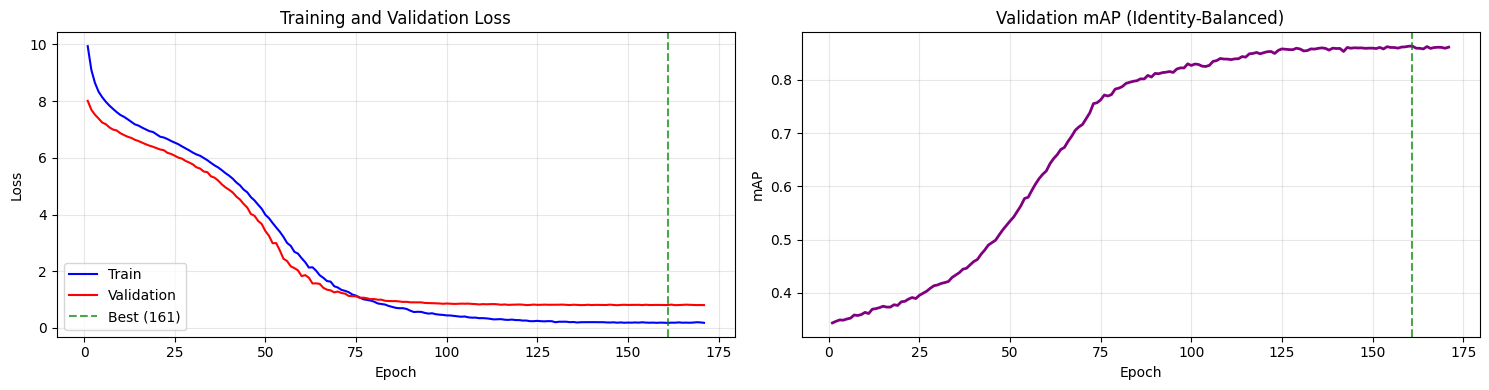

In [57]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_proxyanchor.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_proxyanchor": wandb.Image(fig)})

In [58]:
# Load best model
checkpoint = torch.load(CHECKPOINT_PATH / "model_best_proxyanchor.pth", map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {CHECKPOINT_PATH}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/loss
  Val Loss: 0.8084
  Val mAP: 0.8634


In [59]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(baseline_embeddings).to(device)
    finetuned_embeddings = model(train_tensor).cpu().numpy()
    finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


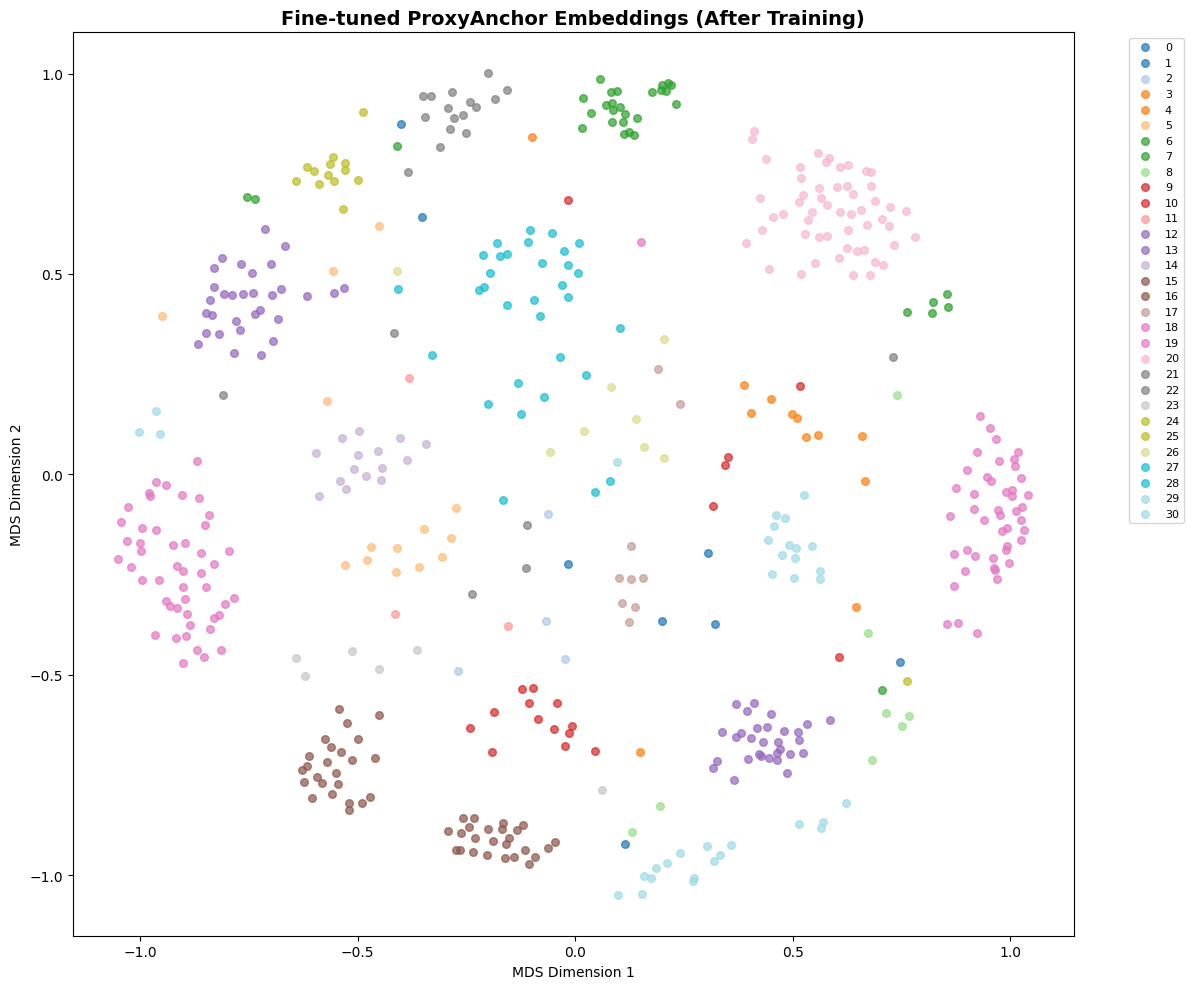

In [60]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Fine-tuned ProxyAnchor Embeddings (After Training)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "proxyanchor_embeddings_mds_finetuned.png")
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds_proxyanchor": wandb.Image(fig_finetuned)})

In [61]:
del optimizer, scheduler, history
torch.cuda.empty_cache()

## Sub-Center ArcFace

In [62]:
class SubCenterArcFaceLoss(nn.Module):
    def __init__(self, num_classes, embedding_dim, k=3, scale=30.0, margin=0.50):
        super().__init__()
        self.scale = scale
        self.margin = margin
        self.k = k
        self.num_classes = num_classes

        self.weight = nn.Parameter(
            torch.randn(num_classes * k, embedding_dim)
        )
        nn.init.xavier_uniform_(self.weight)

    def forward(self, features, labels):
        features = F.normalize(features)
        weight = F.normalize(self.weight)

        cosine = F.linear(features, weight)
        cosine = cosine.view(-1, self.num_classes, self.k)

        cosine, _ = cosine.max(dim=2)  # pick closest sub-center

        theta = torch.acos(torch.clamp(cosine, -1 + 1e-7, 1 - 1e-7))
        target_cosine = torch.cos(theta + self.margin)

        one_hot = F.one_hot(labels, num_classes=self.num_classes).float()

        logits = cosine * (1 - one_hot) + target_cosine * one_hot
        logits *= self.scale
        loss = F.cross_entropy(logits, labels)
    
        return loss


print(f"SubCenterArcFace Model:")
print(f"  Embedding dim: {config['embedding_dim']}")
print(f"  Num classes: {num_classes}")
print(f"  SubCenterArcFace k: {config['subcenter_arcface_num_subcenters']}")
print(f"  SubCenterArcFace margin: {config['subcenter_arcface_margin']}")
print(f"  SubCenterArcFace scale: {config['subcenter_arcface_scale']}")

SubCenterArcFace Model:
  Embedding dim: 256
  Num classes: 31
  SubCenterArcFace k: 3
  SubCenterArcFace margin: 0.5
  SubCenterArcFace scale: 64.0


In [63]:
# Setup training components
model.load_state_dict(torch.load(initial_weights_path))

criterion = SubCenterArcFaceLoss(
    num_classes=num_classes, 
    embedding_dim=config["embedding_dim"], 
    k=config["subcenter_arcface_num_subcenters"],
    margin=config["subcenter_arcface_margin"],
    scale=config["subcenter_arcface_scale"]
).to(device)

optimizer = torch.optim.AdamW(
    list(model.parameters()) + list(criterion.parameters()),
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=5,
)

print("Training components initialized:")
print(f"  Loss: SubCenterArcFaceLoss")
print(f"  Optimizer: AdamW (lr={config['learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)")

Training components initialized:
  Loss: SubCenterArcFaceLoss
  Optimizer: AdamW (lr=0.0001, weight_decay=0.0001)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)


In [64]:
# Training loop
set_seeds(config['seed'])
history, best_map, best_epoch = train(
    model, 
    baseline_emb_train_loader, 
    baseline_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="subcenterarcface"
)

wandb.log({
    "final_val_mAP_subcenterarcface": best_map,
    "best_epoch_subcenterarcface": best_epoch,
    "total_epochs_subcenterarcface": len(history['train_loss']),
})

table.append([
    "SubCenterArcFace",
    best_map,
    best_epoch
])

All random seeds set to 51 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


  Train Loss: 36.4008
  Val Loss:   32.7390
  Val mAP:    0.3440 | LR: 1.00e-04
  [New best model saved]

Epoch 2/200


  Train Loss: 32.6879
  Val Loss:   28.3147
  Val mAP:    0.3588 | LR: 1.00e-04
  [New best model saved]

Epoch 3/200


  Train Loss: 29.3780
  Val Loss:   24.8460
  Val mAP:    0.3767 | LR: 1.00e-04
  [New best model saved]

Epoch 4/200


  Train Loss: 26.6258
  Val Loss:   22.2174
  Val mAP:    0.3906 | LR: 1.00e-04
  [New best model saved]

Epoch 5/200


...

  Train Loss: 0.1076
  Val Loss:   3.1298
  Val mAP:    0.7349 | LR: 2.50e-05
  No improvement. Patience: 6/10

Epoch 132/200


  Train Loss: 0.1299
  Val Loss:   3.1054
  Val mAP:    0.7382 | LR: 1.25e-05
  No improvement. Patience: 7/10

Epoch 133/200


  Train Loss: 0.0867
  Val Loss:   3.1113
  Val mAP:    0.7378 | LR: 1.25e-05
  No improvement. Patience: 8/10

Epoch 134/200


  Train Loss: 0.1099
  Val Loss:   3.0738
  Val mAP:    0.7368 | LR: 1.25e-05
  No improvement. Patience: 9/10

Epoch 135/200


  Train Loss: 0.1187
  Val Loss:   3.0979
  Val mAP:    0.7385 | LR: 1.25e-05
  No improvement. Patience: 10/10

Early stopping triggered after 135 epochs

Training complete!
Best epoch: 125, Val mAP: 0.7390


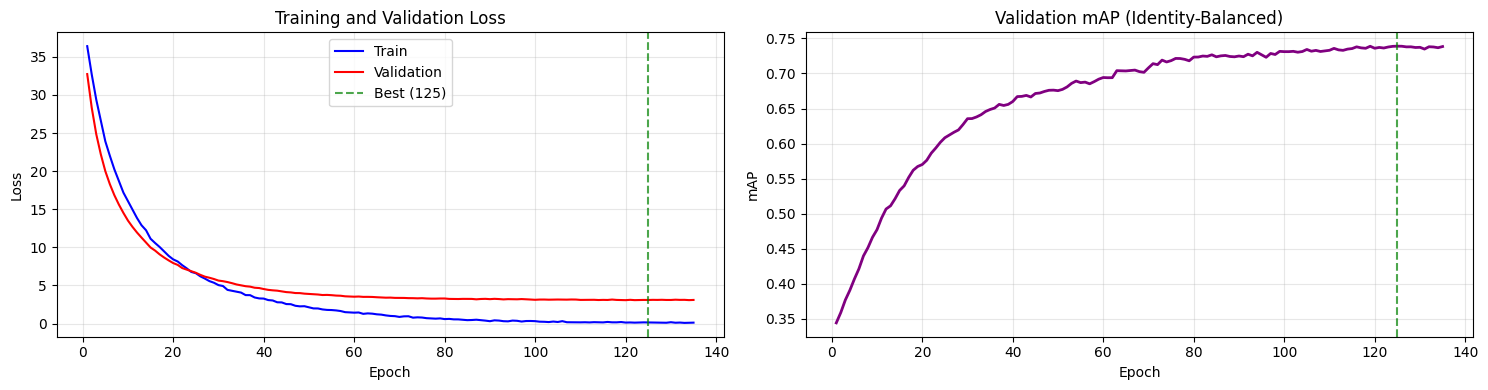

In [65]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_sub_center_arc_face.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_sub_center_arc_face": wandb.Image(fig)})

In [66]:
# Load best model
checkpoint = torch.load(CHECKPOINT_PATH / "model_best_subcenterarcface.pth", map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {CHECKPOINT_PATH}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/loss
  Val Loss: 3.0912
  Val mAP: 0.7390


In [67]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(baseline_embeddings).to(device)
    finetuned_embeddings = model(train_tensor).cpu().numpy()
    finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


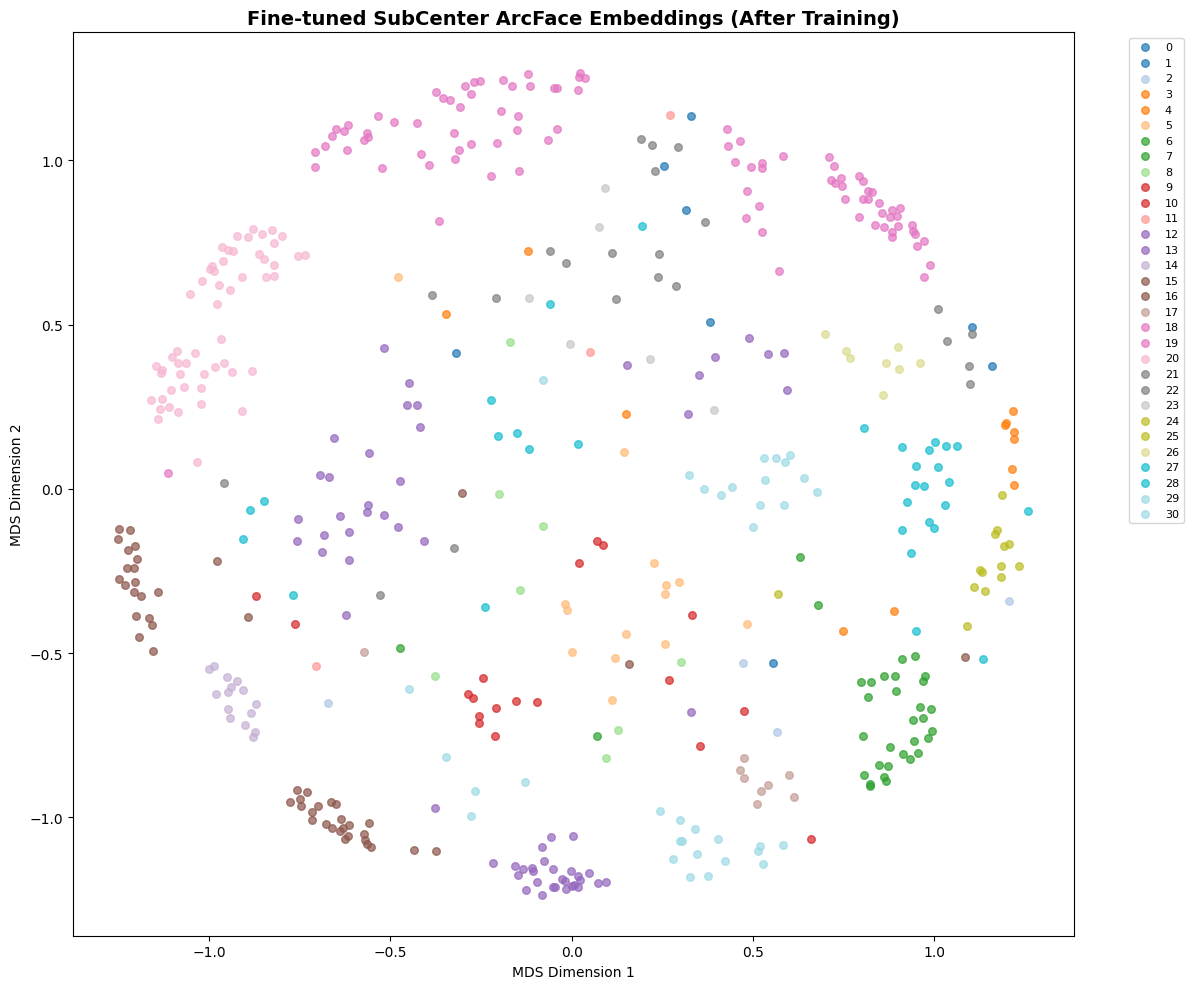

In [68]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Fine-tuned SubCenter ArcFace Embeddings (After Training)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "sub_center_arc_face_embeddings_mds_finetuned.png")
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds_sub_center_arc_face": wandb.Image(fig_finetuned)})

In [69]:
del optimizer, scheduler, history
torch.cuda.empty_cache()

## Center Loss

In [70]:
class CenterLoss(nn.Module):
    def __init__(self, embedding_dim, num_classes):
        super().__init__()
        self.centers = nn.Parameter(torch.randn(num_classes, embedding_dim))

    def forward(self, features, labels):
        centers_batch = self.centers[labels]
        loss = ((features - centers_batch) ** 2).sum(dim=1).mean()
        return loss

print(f"Center Loss:")
print(f"  Embedding dim: {config['embedding_dim']}")
print(f"  Num classes: {num_classes}")

Center Loss:
  Embedding dim: 256
  Num classes: 31


In [71]:
# Setup training components
model.load_state_dict(torch.load(initial_weights_path))

criterion = CenterLoss(
    embedding_dim=config["embedding_dim"],
    num_classes=num_classes
).to(device)

optimizer = torch.optim.AdamW(
    list(model.parameters()) + list(criterion.parameters()),
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=5,
)

print("Training components initialized:")
print(f"  Loss: CenterLoss")
print(f"  Optimizer: AdamW (lr={config['learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)")

Training components initialized:
  Loss: CenterLoss
  Optimizer: AdamW (lr=0.0001, weight_decay=0.0001)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)


In [72]:
# Training loop
set_seeds(config['seed'])
history, best_map, best_epoch = train(
    model, 
    baseline_emb_train_loader, 
    baseline_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="center_loss"
)

wandb.log({
    "final_val_mAP_center_loss": best_map,
    "best_epoch_center_loss": best_epoch,
    "total_epochs_center_loss": len(history['train_loss']),
})

table.append([
    "Center Loss",
    best_map,
    best_epoch
])

All random seeds set to 51 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


  Train Loss: 489.7425
  Val Loss:   366.1552
  Val mAP:    0.3504 | LR: 1.00e-04
  [New best model saved]

Epoch 2/200


  Train Loss: 439.2787
  Val Loss:   333.2690
  Val mAP:    0.3680 | LR: 1.00e-04
  [New best model saved]

Epoch 3/200


  Train Loss: 398.9173
  Val Loss:   305.1308
  Val mAP:    0.3880 | LR: 1.00e-04
  [New best model saved]

Epoch 4/200


  Train Loss: 366.6157
  Val Loss:   279.9178
  Val mAP:    0.4123 | LR: 1.00e-04
  [New best model saved]

Epoch 5/200


...

  Train Loss: 23.0756
  Val Loss:   24.9662
  Val mAP:    0.8548 | LR: 1.00e-04
  No improvement. Patience: 6/10

Epoch 180/200


  Train Loss: 22.0955
  Val Loss:   24.7661
  Val mAP:    0.8539 | LR: 1.00e-04
  No improvement. Patience: 7/10

Epoch 181/200


  Train Loss: 22.5410
  Val Loss:   24.7937
  Val mAP:    0.8548 | LR: 1.00e-04
  No improvement. Patience: 8/10

Epoch 182/200


  Train Loss: 21.9674
  Val Loss:   24.8629
  Val mAP:    0.8542 | LR: 1.00e-04
  No improvement. Patience: 9/10

Epoch 183/200


  Train Loss: 22.2534
  Val Loss:   24.5763
  Val mAP:    0.8543 | LR: 1.00e-04
  No improvement. Patience: 10/10

Early stopping triggered after 183 epochs

Training complete!
Best epoch: 173, Val mAP: 0.8554


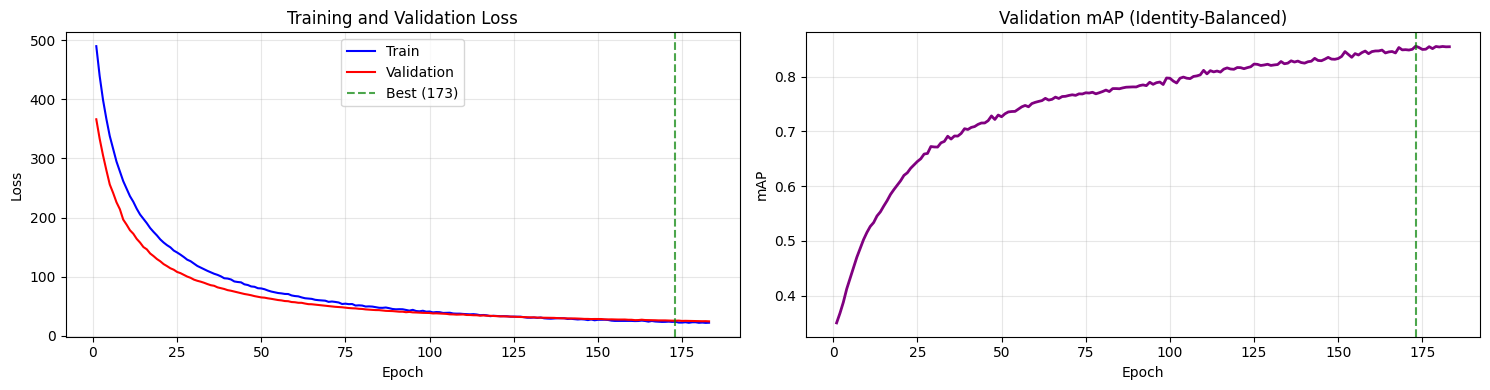

In [73]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_center_loss.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_center_loss": wandb.Image(fig)})

In [74]:
# Load best model
checkpoint = torch.load(CHECKPOINT_PATH / "model_best_center_loss.pth", map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {CHECKPOINT_PATH}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/loss
  Val Loss: 25.6571
  Val mAP: 0.8554


In [75]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(baseline_embeddings).to(device)
    finetuned_embeddings = model(train_tensor).cpu().numpy()
    finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


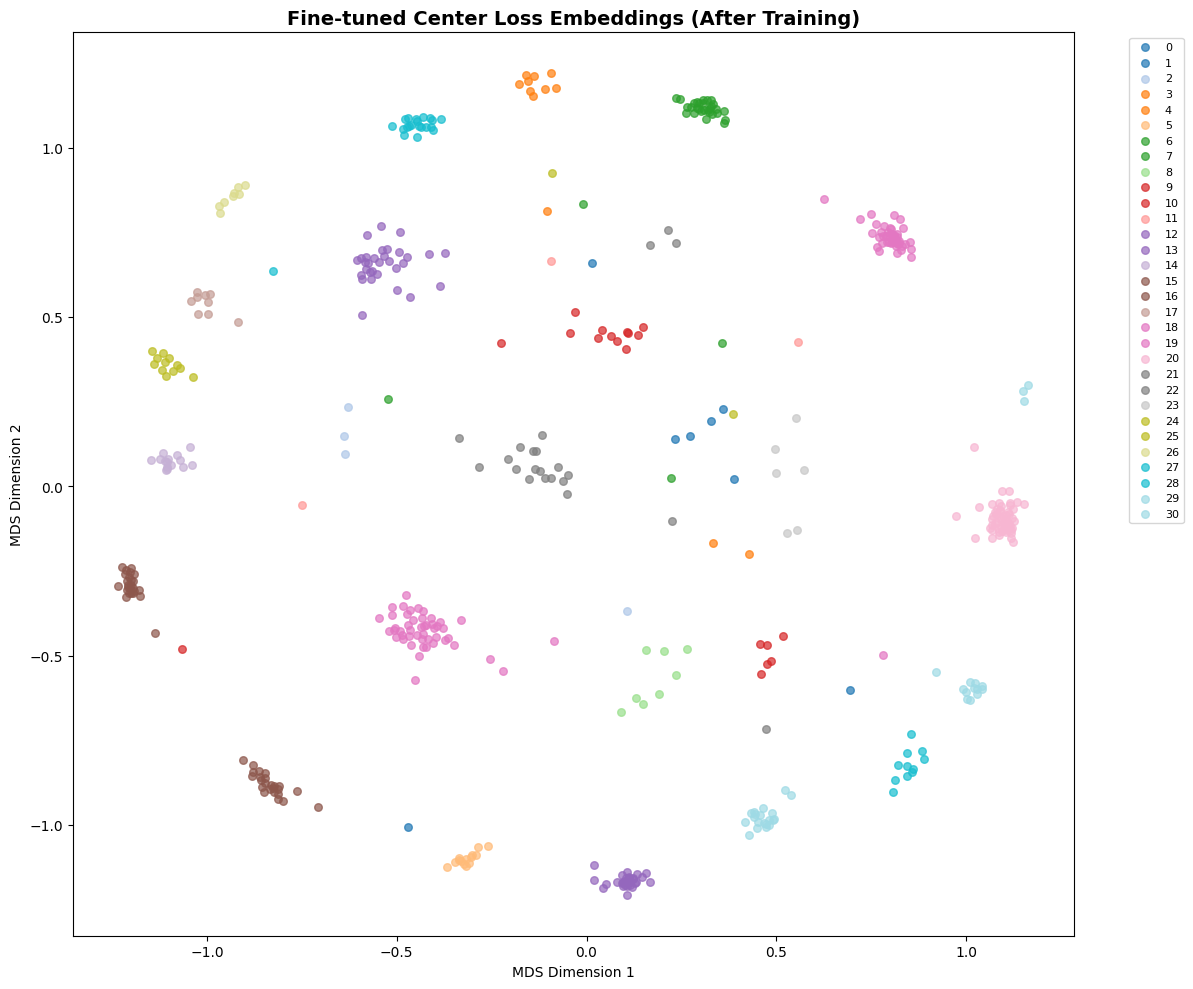

In [76]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Fine-tuned Center Loss Embeddings (After Training)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "center_loss_embeddings_mds_finetuned.png")
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds_center_loss": wandb.Image(fig_finetuned)})

In [77]:
del optimizer, scheduler, history
torch.cuda.empty_cache()

## Batch-Hard Triplet Loss

In [78]:
class BatchHardTripletLoss(nn.Module):
    def __init__(self, margin=0.3):
        super().__init__()
        self.margin = margin

    def forward(self, features, labels):
        features = F.normalize(features)
        dist = torch.cdist(features, features, p=2)

        labels = labels.unsqueeze(1)
        mask_pos = labels.eq(labels.T)
        mask_neg = ~mask_pos

        hardest_pos = (dist * mask_pos.float()).max(dim=1)[0]

        dist_neg = dist.clone()
        dist_neg[~mask_neg] = float('inf')
        hardest_neg = dist_neg.min(dim=1)[0]

        loss = F.relu(hardest_pos - hardest_neg + self.margin)
        return loss.mean()

print(f"Batch Hard Triplet Loss:")
print(f"  Margin: {config['batch_hard_triplet_margin']}")

Batch Hard Triplet Loss:
  Margin: 0.3


In [79]:
# Setup training components
model.load_state_dict(torch.load(initial_weights_path))

criterion = BatchHardTripletLoss(
    margin=config["batch_hard_triplet_margin"]
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=5,
)

print("Training components initialized:")
print(f"  Loss: BatchHardTripletLoss")
print(f"  Optimizer: AdamW (lr={config['learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)")

Training components initialized:
  Loss: BatchHardTripletLoss
  Optimizer: AdamW (lr=0.0001, weight_decay=0.0001)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)


In [80]:
# Training loop
set_seeds(config['seed'])
history, best_map, best_epoch = train(
    model, 
    baseline_emb_train_loader, 
    baseline_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="batch_hard_triplet"
)

wandb.log({
    "final_val_mAP_batch_hard_triplet": best_map,
    "best_epoch_batch_hard_triplet": best_epoch,
    "total_epochs_batch_hard_triplet": len(history['train_loss']),
})

table.append([
    "Batch Hard Triplet",
    best_map,
    best_epoch
])

All random seeds set to 51 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


  Train Loss: 0.2967
  Val Loss:   0.4583
  Val mAP:    0.3815 | LR: 1.00e-04
  [New best model saved]

Epoch 2/200


  Train Loss: 0.2757
  Val Loss:   0.4243
  Val mAP:    0.4109 | LR: 1.00e-04
  [New best model saved]

Epoch 3/200


  Train Loss: 0.2686
  Val Loss:   0.4031
  Val mAP:    0.4296 | LR: 1.00e-04
  [New best model saved]

Epoch 4/200


  Train Loss: 0.2625
  Val Loss:   0.3872
  Val mAP:    0.4510 | LR: 1.00e-04
  [New best model saved]

Epoch 5/200


...

  Train Loss: 0.0158
  Val Loss:   0.0801
  Val mAP:    0.7475 | LR: 1.00e-04
  No improvement. Patience: 6/10

Epoch 92/200


  Train Loss: 0.0149
  Val Loss:   0.0781
  Val mAP:    0.7490 | LR: 1.00e-04
  No improvement. Patience: 7/10

Epoch 93/200


  Train Loss: 0.0167
  Val Loss:   0.0772
  Val mAP:    0.7501 | LR: 1.00e-04
  No improvement. Patience: 8/10

Epoch 94/200


  Train Loss: 0.0141
  Val Loss:   0.0792
  Val mAP:    0.7482 | LR: 1.00e-04
  No improvement. Patience: 9/10

Epoch 95/200


  Train Loss: 0.0116
  Val Loss:   0.0772
  Val mAP:    0.7528 | LR: 1.00e-04
  No improvement. Patience: 10/10

Early stopping triggered after 95 epochs

Training complete!
Best epoch: 85, Val mAP: 0.7536


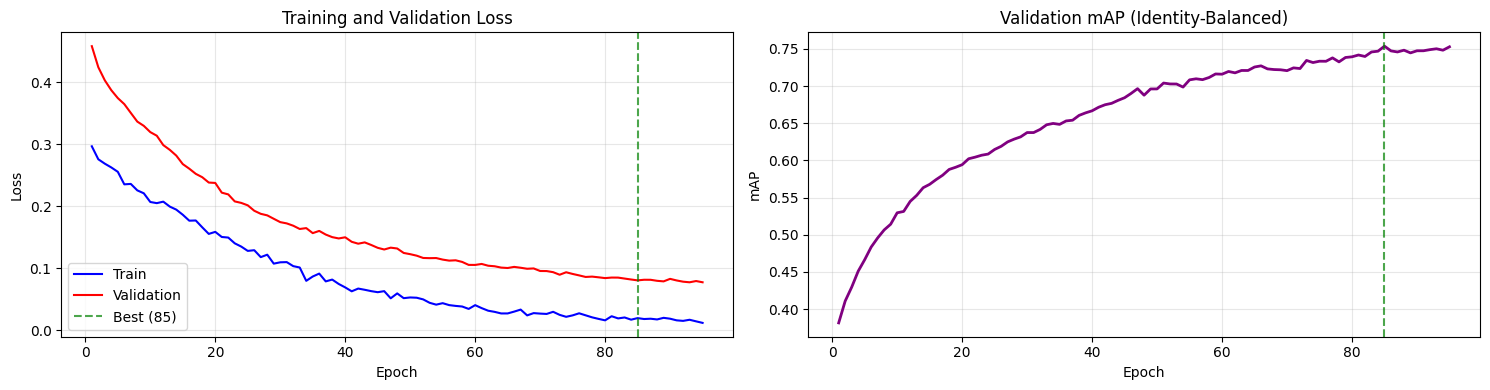

In [81]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_batch_hard_triplet.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_batch_hard_triplet": wandb.Image(fig)})

In [82]:
# Load best model
checkpoint = torch.load(CHECKPOINT_PATH / "model_best_batch_hard_triplet.pth", map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {CHECKPOINT_PATH}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/loss
  Val Loss: 0.0803
  Val mAP: 0.7536


In [83]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(baseline_embeddings).to(device)
    finetuned_embeddings = model(train_tensor).cpu().numpy()
    finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


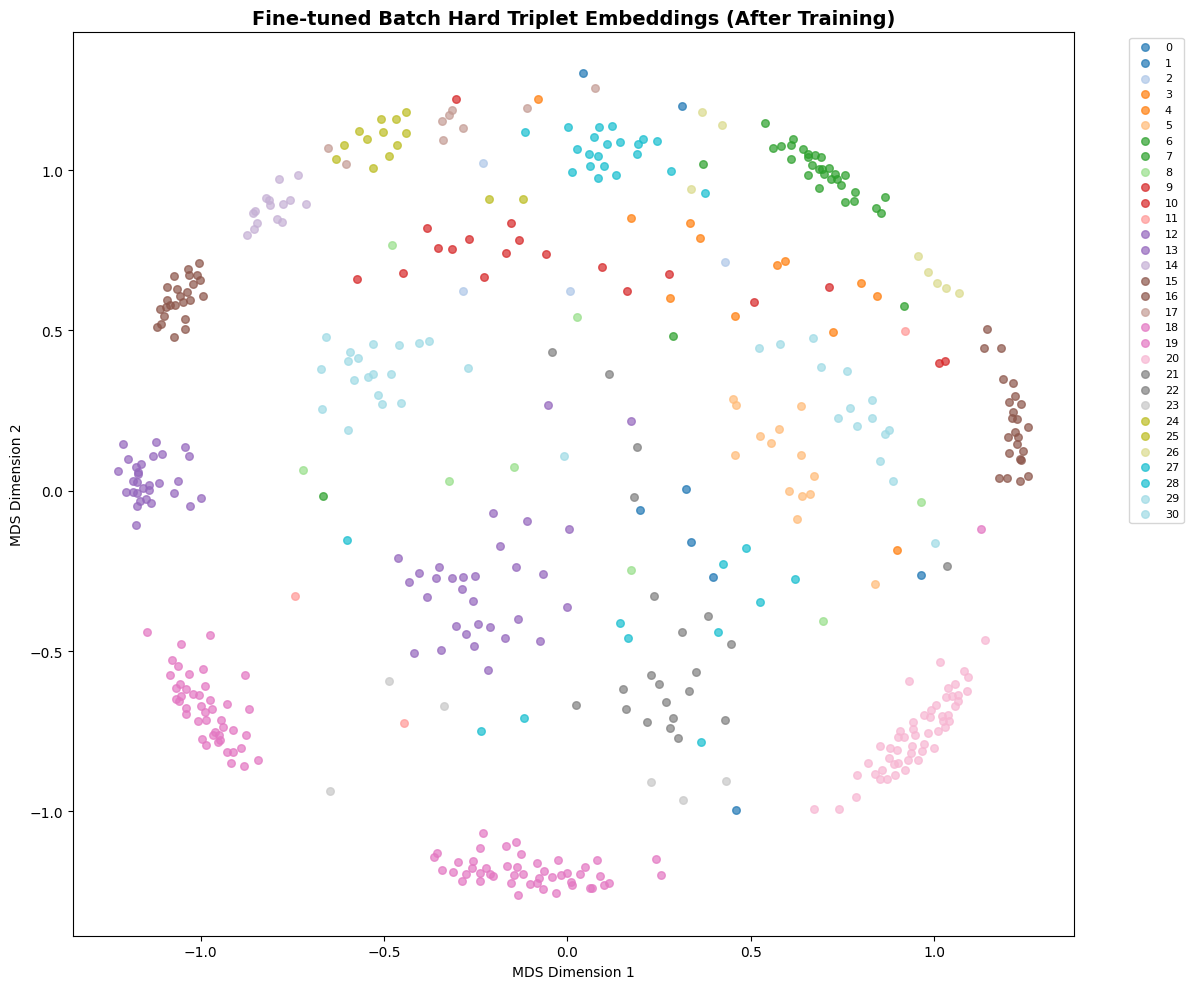

In [84]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Fine-tuned Batch Hard Triplet Embeddings (After Training)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "batch_hard_triplet_embeddings_mds_finetuned.png")
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds_batch_hard_triplet": wandb.Image(fig_finetuned)})

In [85]:
del optimizer, scheduler, history
torch.cuda.empty_cache()

## Summary

In [86]:
rows = list(zip(*table)) # transpose for tabulate
print(tabulate(rows[1:], headers=rows[0], tablefmt="grid"))

+-----------------+-----------+-----------+--------------+---------------+--------------------+---------------+----------------------+
| Loss Function   |   ArcFace |   CosFace |   SphereFace |   ProxyAnchor |   SubCenterArcFace |   Center Loss |   Batch Hard Triplet |
+=================+===========+===========+==============+===============+====================+===============+======================+
| Best val_mAP    |  0.842345 |  0.835787 |     0.862291 |      0.863393 |           0.738997 |      0.855357 |             0.753633 |
+-----------------+-----------+-----------+--------------+---------------+--------------------+---------------+----------------------+
| Best epoch      | 94        | 77        |   166        |    161        |         125        |    173        |            85        |
+-----------------+-----------+-----------+--------------+---------------+--------------------+---------------+----------------------+
